In [20]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
CLEANED_DIR  = '/Users/zahidahmed/Documents/Stats/ST422/Data Prep/Cleaned Data'

BASE_YEARS   = [2015, 2016, 2017]   # early 3-year window
RECENT_YEARS = [2022, 2023, 2024]   # recent 3-year window (excludes COVID)
MIN_KSI_BASE = 30                   # min avg KSI in base window to include LA
TOP_N        = 5                    # priority list size (tables + factor charts)
TOP_N_LINES  = 3                    # LAs shown in trend line charts (readability)
# ──────────────────────────────────────────────────────────────────────────────

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'figure.dpi': 120
})

cas = pd.read_csv(
    f'{CLEANED_DIR}/cas_full.csv',
    dtype={'collision_index': str},
    low_memory=False
)

# KSI only, confirmed years, LA name present
ksi = cas[
    cas['ksi'].eq(True) &
    cas['provisional'].eq(False) &
    cas['la_name'].notna()
].copy()

print(f'KSI records: {len(ksi):,}')
print(f'Years: {sorted(ksi["collision_year"].dropna().unique().astype(int).tolist())}')

KSI records: 360,128
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [22]:
# 3-year average KSI per LA — base and recent windows

def window_avg(df, years):
    return (
        df[df['collision_year'].isin(years)]
        .groupby('la_name')
        .size()
        .div(len(years))
        .reset_index(name='ksi_avg')
    )

# Completeness filter — only keep LAs with records in ALL years of both windows.
# This drops LAs that were reorganised or renamed mid-window (e.g. Harrogate → North Yorkshire).
def complete_las(df, years):
    return set(
        df[df['collision_year'].isin(years)]
        .groupby('la_name')['collision_year']
        .nunique()
        .pipe(lambda s: s[s == len(years)].index)
    )

complete = complete_las(ksi, BASE_YEARS) & complete_las(ksi, RECENT_YEARS)
ksi_complete = ksi[ksi['la_name'].isin(complete)].copy()
print(f'LAs with complete data in both windows: {len(complete)}')
print(f'LAs dropped (boundary/reorganisation): {ksi["la_name"].nunique() - len(complete)}')

base   = window_avg(ksi_complete, BASE_YEARS).rename(columns={'ksi_avg': 'base_avg'})
recent = window_avg(ksi_complete, RECENT_YEARS).rename(columns={'ksi_avg': 'recent_avg'})

la_change = base.merge(recent, on='la_name', how='inner')
la_change = la_change[la_change['base_avg'] >= MIN_KSI_BASE].copy()

la_change['absolute_rise'] = la_change['recent_avg'] - la_change['base_avg']
la_change['pct_change']    = la_change['absolute_rise'] / la_change['base_avg'] * 100

la_change['trend_flag'] = pd.cut(
    la_change['pct_change'],
    bins=[-np.inf, -15, 15, np.inf],
    labels=['Improving', 'Stable', 'Worsening']
)

print(f'\nLAs included after size filter (base avg >= {MIN_KSI_BASE}): {len(la_change)}')
print(la_change['trend_flag'].value_counts().to_string())

LAs with complete data in both windows: 339
LAs dropped (boundary/reorganisation): 53

LAs included after size filter (base avg >= 30): 322
trend_flag
Stable       126
Worsening    120
Improving     76


In [23]:
# Robustness check — three weighting schemes
# 60/40 primary: absolute rise weighted more (client priority = reducing total harm)

SCHEMES = {'50/50': (0.5, 0.5), '60/40': (0.6, 0.4), '70/30': (0.7, 0.3)}

worsening = la_change[la_change['trend_flag'] == 'Worsening'].copy()

worsening['norm_abs'] = (
    (worsening['absolute_rise'] - worsening['absolute_rise'].min()) /
    (worsening['absolute_rise'].max() - worsening['absolute_rise'].min())
)
worsening['norm_pct'] = (
    (worsening['pct_change'] - worsening['pct_change'].min()) /
    (worsening['pct_change'].max() - worsening['pct_change'].min())
)

robustness_rows = []
for scheme, (abs_w, pct_w) in SCHEMES.items():
    tmp = worsening.copy()
    tmp['composite'] = abs_w * tmp['norm_abs'] + pct_w * tmp['norm_pct']
    tmp = tmp.sort_values('composite', ascending=False).reset_index(drop=True)
    tmp['rank']   = tmp.index + 1
    tmp['scheme'] = scheme
    robustness_rows.append(tmp[['la_name', 'rank', 'scheme', 'composite',
                                 'absolute_rise', 'pct_change']])

robustness = pd.concat(robustness_rows, ignore_index=True)

# Primary ranking — 60/40
primary = robustness[robustness['scheme'] == '60/40'].sort_values('rank')

# Rank stability across schemes
rank_stability = (
    robustness[robustness['rank'] <= TOP_N]
    .groupby('la_name')['rank']
    .agg(min_rank='min', max_rank='max')
    .assign(rank_range=lambda x: x['max_rank'] - x['min_rank'])
    .assign(stable=lambda x: x['rank_range'] < 3)
    .reset_index()
    .sort_values('min_rank')
)

# Wide comparison table
robustness_wide = (
    robustness[robustness['rank'] <= TOP_N]
    .pivot(index='rank', columns='scheme', values='la_name')
    [['50/50', '60/40', '70/30']]
)

print('=== Rank comparison across weighting schemes (top 5) ===')
print(robustness_wide.to_string())
print('\n=== Rank stability ===')
print(rank_stability.to_string(index=False))

=== Rank comparison across weighting schemes (top 5) ===
scheme      50/50      60/40      70/30
rank                                   
1        Bradford   Bradford      Leeds
2           Leeds      Leeds   Bradford
3        Highland   Highland   Highland
4       Southwark  Southwark  Southwark
5          Sutton    Croydon    Croydon

=== Rank stability ===
  la_name  min_rank  max_rank  rank_range  stable
 Bradford         1         2           1    True
    Leeds         1         2           1    True
 Highland         3         3           0    True
Southwark         4         4           0    True
  Croydon         5         5           0    True
   Sutton         5         5           0    True


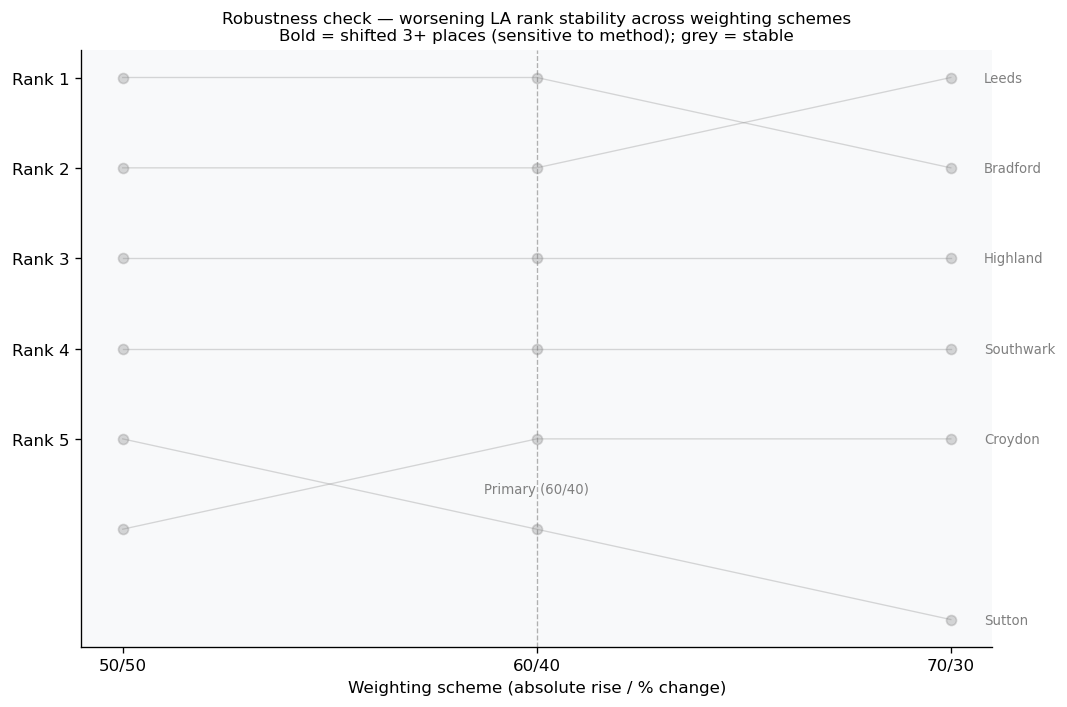

In [24]:
# Bump chart — rank stability across weighting schemes

top_las   = robustness[robustness['rank'] <= TOP_N]['la_name'].unique()
stable_las = rank_stability[rank_stability['stable']]['la_name'].tolist()
plot_df   = robustness[robustness['la_name'].isin(top_las)].copy()
plot_df['scheme'] = pd.Categorical(plot_df['scheme'],
                                    categories=['50/50', '60/40', '70/30'], ordered=True)

fig, ax = plt.subplots(figsize=(9, 6))

for la in top_las:
    sub = plot_df[plot_df['la_name'] == la].sort_values('scheme')
    is_stable = la in stable_las
    ax.plot(
        sub['scheme'].cat.codes, sub['rank'],
        color='grey' if is_stable else None,
        alpha=0.3 if is_stable else 1.0,
        linewidth=0.8 if is_stable else 2.0,
        marker='o', markersize=6
    )
    row_end = sub[sub['scheme'] == '70/30']
    if not row_end.empty:
        ax.text(2.08, row_end['rank'].values[0], la,
                va='center', fontsize=8,
                color='grey' if is_stable else 'black',
                fontweight='normal' if is_stable else 'bold')

ax.axvline(1, linestyle='--', color='grey', linewidth=0.8, alpha=0.6)
ax.text(1, TOP_N + 0.6, 'Primary (60/40)', ha='center', fontsize=8, color='grey')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['50/50', '60/40', '70/30'])
ax.set_yticks(range(1, TOP_N + 1))
ax.set_yticklabels([f'Rank {i}' for i in range(1, TOP_N + 1)])
ax.invert_yaxis()
ax.set_xlabel('Weighting scheme (absolute rise / % change)')
ax.set_title(
    'Robustness check — worsening LA rank stability across weighting schemes\n'
    'Bold = shifted 3+ places (sensitive to method); grey = stable',
    fontsize=10
)
plt.tight_layout()
plt.show()

In [25]:
# Final priority table — top 5 worsening LAs (60/40 primary)

top5 = (
    primary[['la_name', 'rank', 'absolute_rise', 'pct_change']]
    .head(TOP_N)
    .merge(worsening[['la_name', 'base_avg', 'recent_avg', 'trend_flag']], on='la_name')
    .merge(rank_stability[['la_name', 'rank_range', 'stable']], on='la_name')
    .round(1)
)

top5_names      = top5['la_name'].tolist()
top3_line_names = top5_names[:TOP_N_LINES]

print('=== Top 5 worsening LAs (60/40 composite, 3-yr avg) ===')
print(top5[['rank', 'la_name', 'base_avg', 'recent_avg',
            'absolute_rise', 'pct_change', 'rank_range', 'stable']].to_string(index=False))

=== Top 5 worsening LAs (60/40 composite, 3-yr avg) ===
 rank   la_name  base_avg  recent_avg  absolute_rise  pct_change  rank_range  stable
    1  Bradford     228.7       414.3          185.7        81.2           1    True
    2     Leeds     413.7       642.0          228.3        55.2           1    True
    3  Highland     121.7       238.0          116.3        95.6           0    True
    4 Southwark     114.7       215.3          100.7        87.8           0    True
    5   Croydon     106.0       189.0           83.0        78.3           0    True


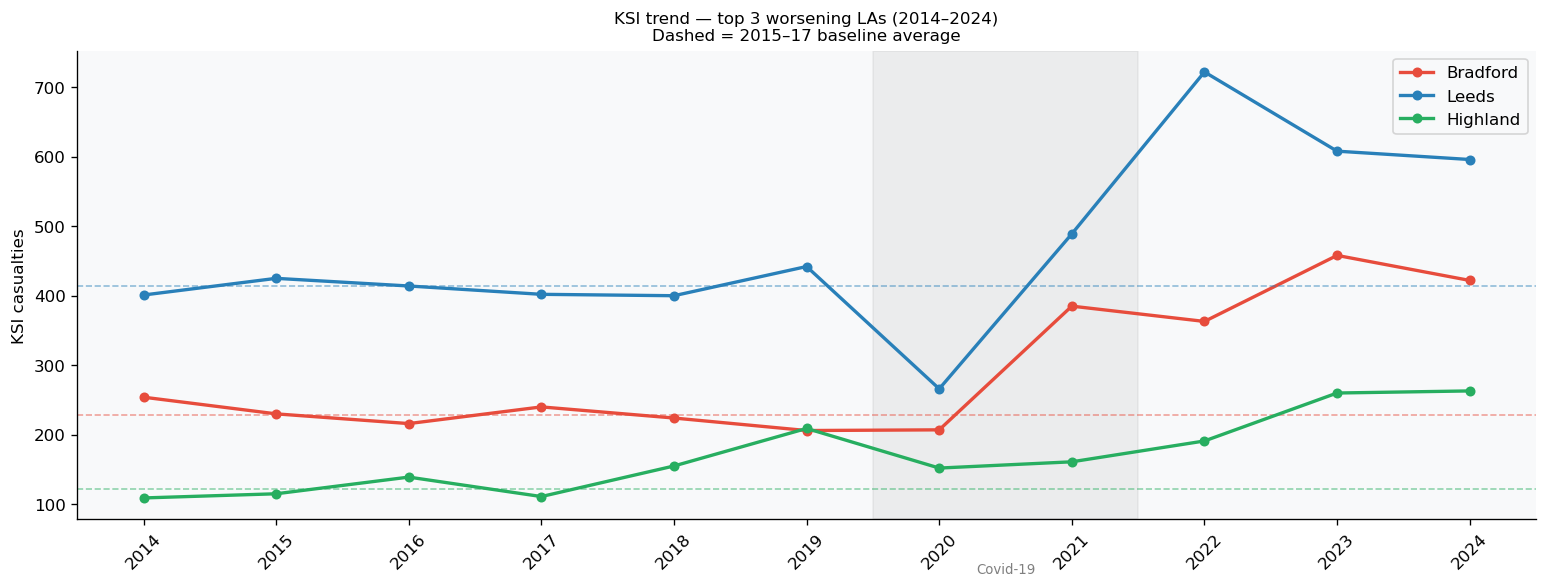

In [26]:
# Annual KSI trend — top 3 LAs only (line chart)
# Dashed reference = base window average

annual = (
    ksi_complete[ksi_complete['la_name'].isin(top3_line_names)]
    .groupby(['la_name', 'collision_year'])
    .size()
    .reset_index(name='KSI')
)

base_ref = worsening.set_index('la_name')['base_avg']
palette  = ['#e74c3c', '#2980b9', '#27ae60']
la_colors = dict(zip(top3_line_names, palette))

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(2019.5, 2021.5, alpha=0.10, color='grey')
ax.text(2020.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
        'Covid-19', ha='center', fontsize=8, color='grey')

for la in top3_line_names:
    sub = annual[annual['la_name'] == la]
    c = la_colors[la]
    ax.plot(sub['collision_year'], sub['KSI'],
            color=c, lw=2, marker='o', ms=5, label=la)
    ax.axhline(base_ref[la], color=c, linestyle='--', lw=1, alpha=0.5)

ax.set_title(
    'KSI trend — top 3 worsening LAs (2014–2024)\n'
    'Dashed = 2015–17 baseline average',
    fontsize=10
)
ax.set_xlabel(None)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014, 2025))
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

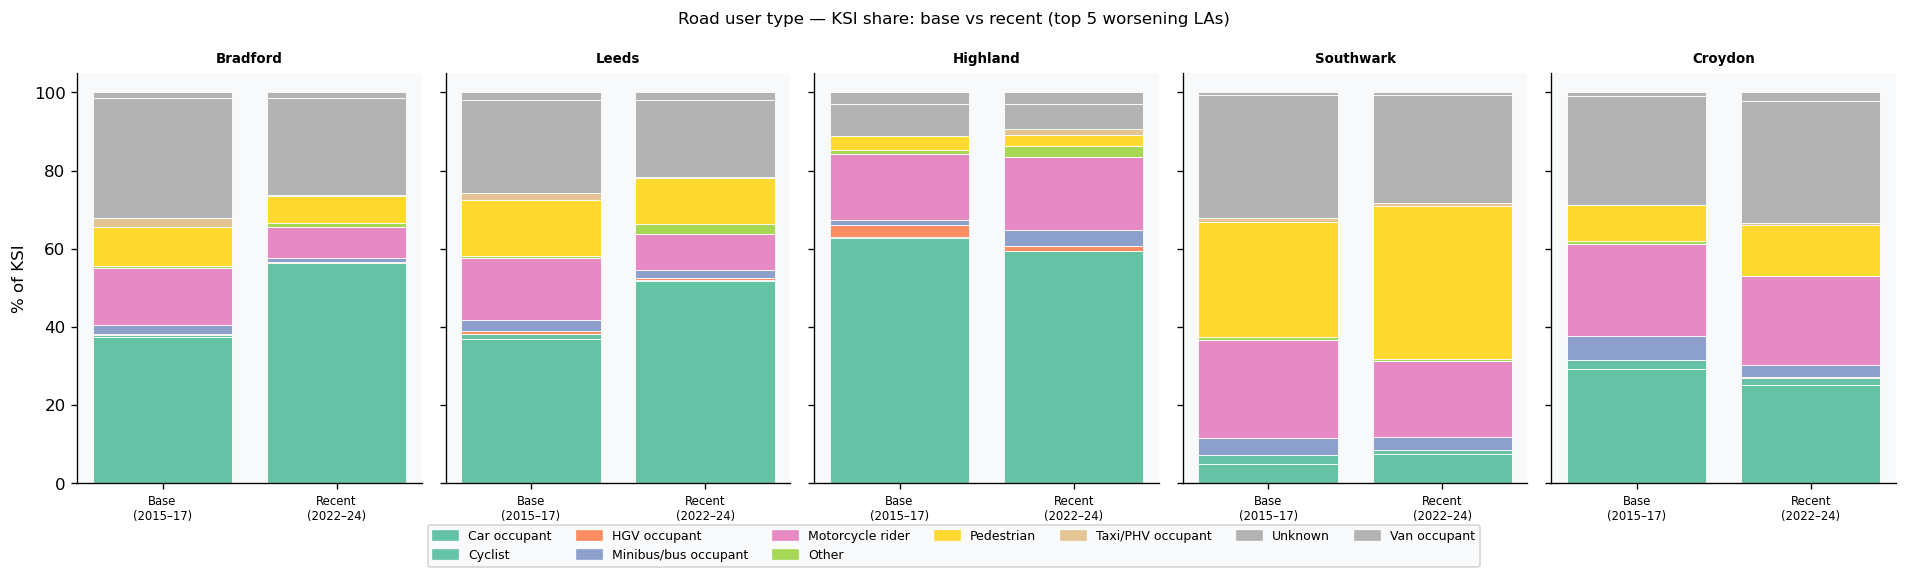

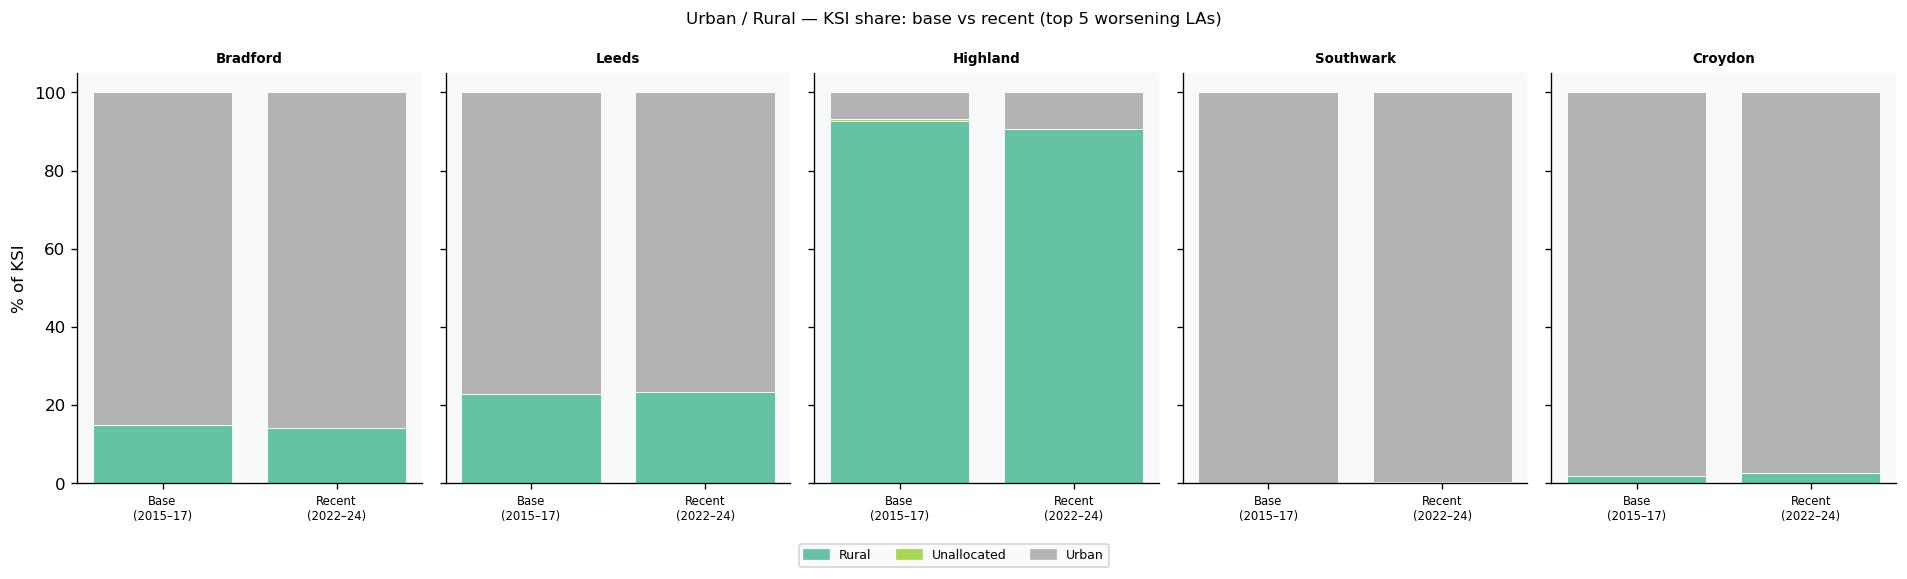

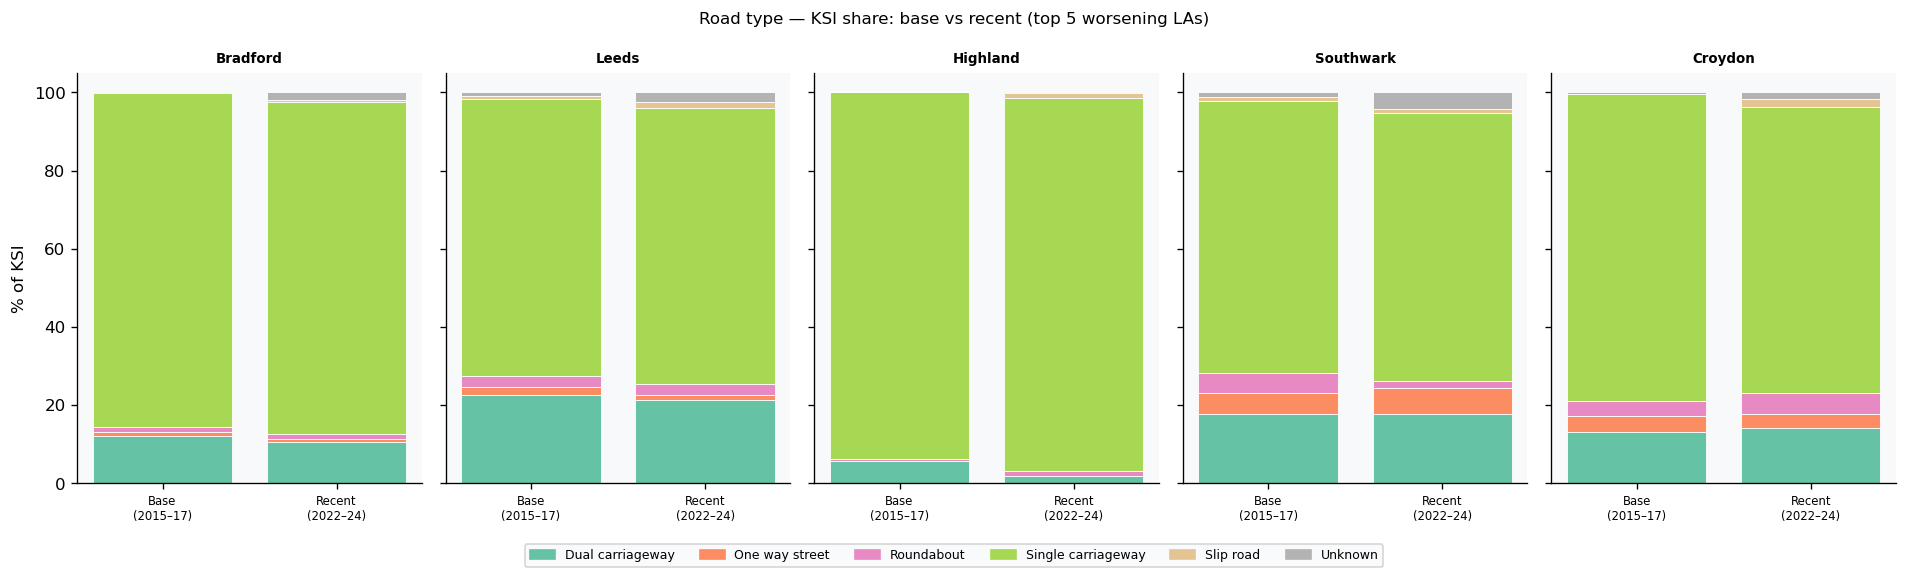

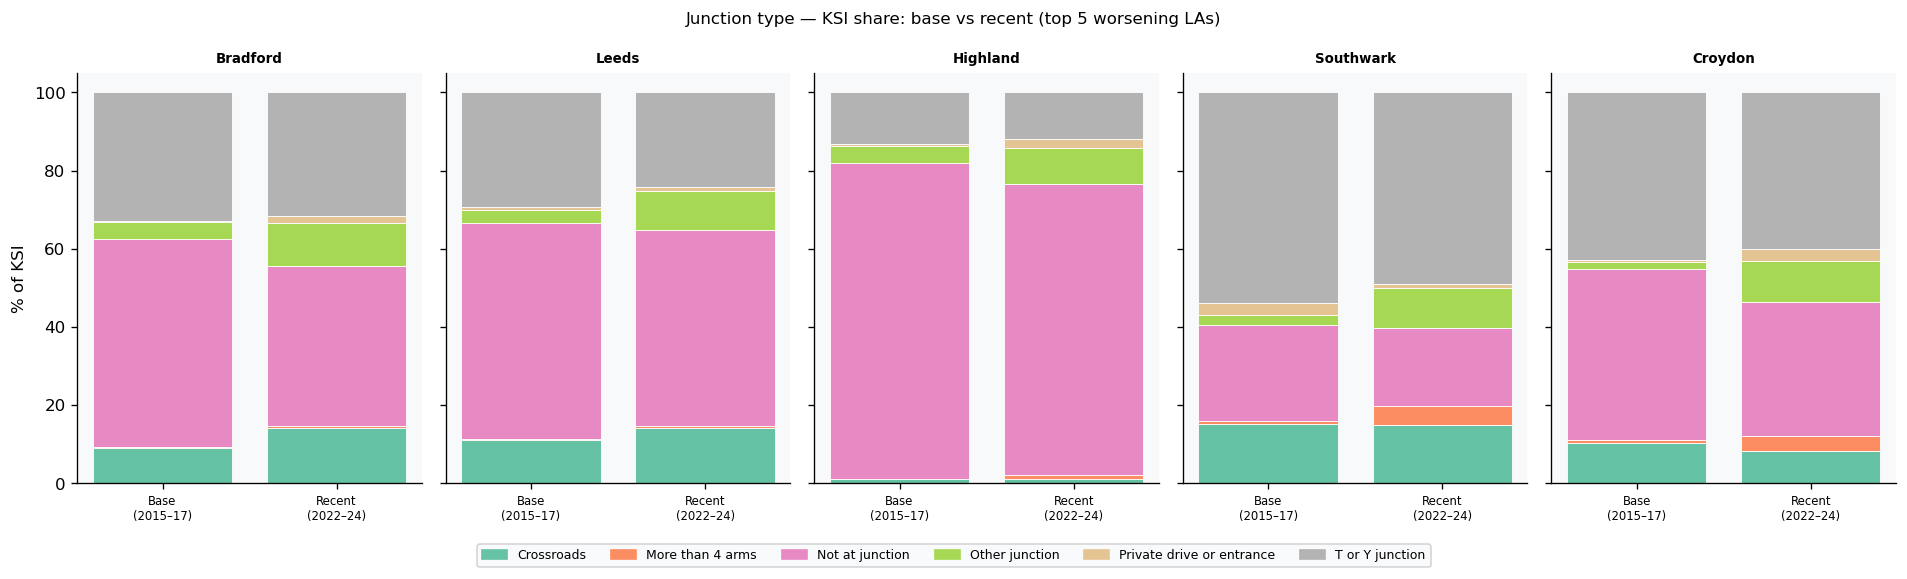

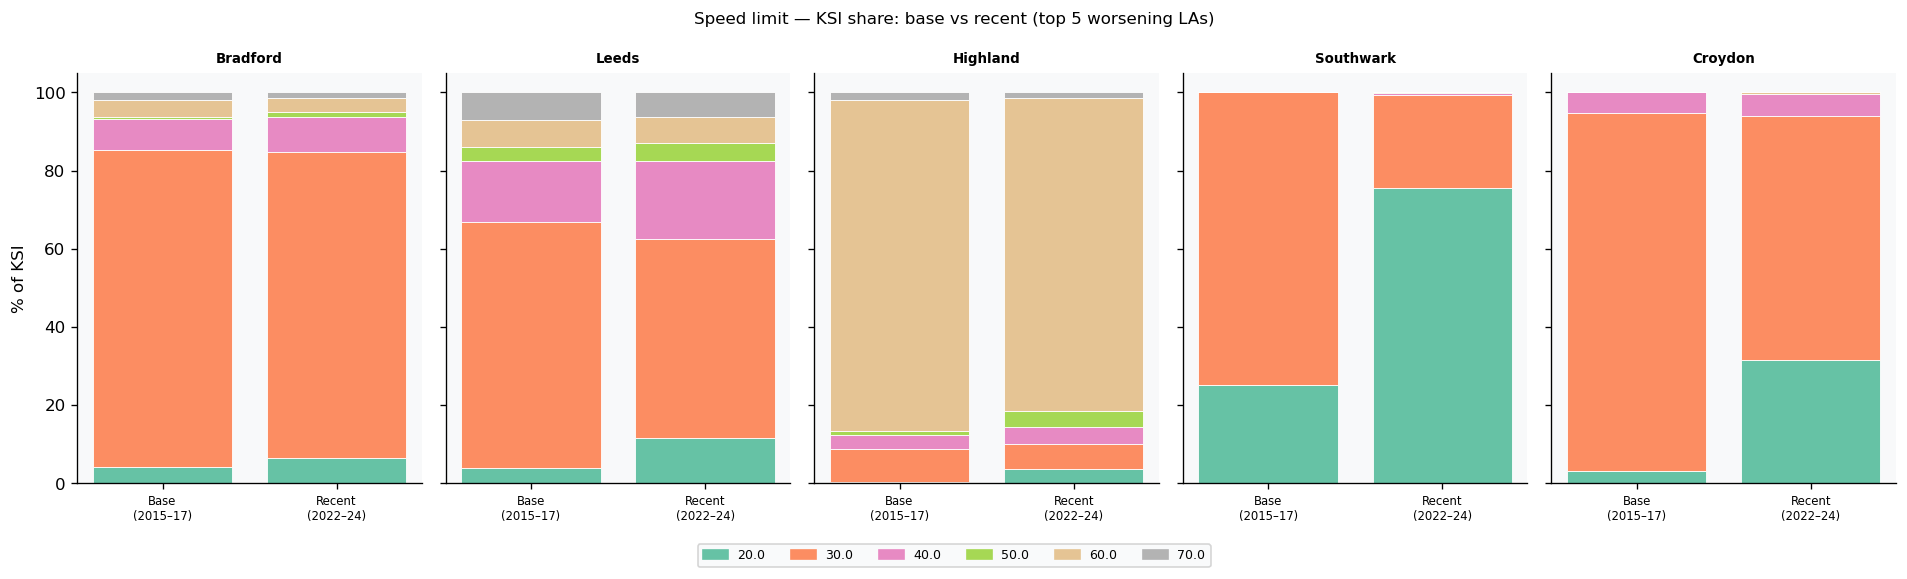

In [27]:
# Factor breakdown — base vs recent KSI share for all top 5 LAs
# One chart per factor, one bar pair per LA

FACTORS = [
    ('road_user',       'Road user type'),
    ('ur_label',        'Urban / Rural'),
    ('road_type_label', 'Road type'),
    ('junction_label',  'Junction type'),
    ('speed_limit',     'Speed limit'),
]

deep = ksi_complete[
    ksi['la_name'].isin(top5_names) &
    ksi['collision_year'].isin(BASE_YEARS + RECENT_YEARS)
].copy()
deep['window'] = deep['collision_year'].apply(
    lambda y: 'Base\n(2015–17)' if y in BASE_YEARS else 'Recent\n(2022–24)'
)

for col, label in FACTORS:
    if col not in deep.columns:
        print(f'{col} not found — skipping')
        continue

    grp = (
        deep[deep[col].notna()]
        .groupby(['la_name', 'window', col])
        .size()
        .reset_index(name='KSI')
    )
    grp['pct'] = grp.groupby(['la_name', 'window'])['KSI'].transform(
        lambda x: x / x.sum() * 100
    )

    cats = sorted(grp[col].dropna().unique().astype(str))
    cmap = plt.cm.get_cmap('Set2', len(cats))
    cat_colors = {c: cmap(i) for i, c in enumerate(cats)}

    fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=True)
    fig.suptitle(f'{label} — KSI share: base vs recent (top 5 worsening LAs)', fontsize=10)

    windows = ['Base\n(2015–17)', 'Recent\n(2022–24)']
    for ax, la in zip(axes, top5_names):
        sub = grp[grp['la_name'] == la]
        bottoms = [0, 0]
        for cat in cats:
            vals = []
            for w in windows:
                row = sub[(sub['window'] == w) & (sub[col].astype(str) == cat)]
                vals.append(row['pct'].values[0] if not row.empty else 0)
            ax.bar(windows, vals, bottom=bottoms,
                   color=cat_colors[cat], label=cat,
                   edgecolor='white', linewidth=0.5)
            bottoms = [b + v for b, v in zip(bottoms, vals)]

        ax.set_title(la, fontsize=8, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.tick_params(axis='x', labelsize=7)
        if ax == axes[0]:
            ax.set_ylabel('% of KSI')

    handles = [plt.Rectangle((0, 0), 1, 1, color=cat_colors[c]) for c in cats]
    fig.legend(handles, cats, loc='lower center',
               ncol=min(len(cats), 7), fontsize=7.5,
               bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout()
    plt.show()

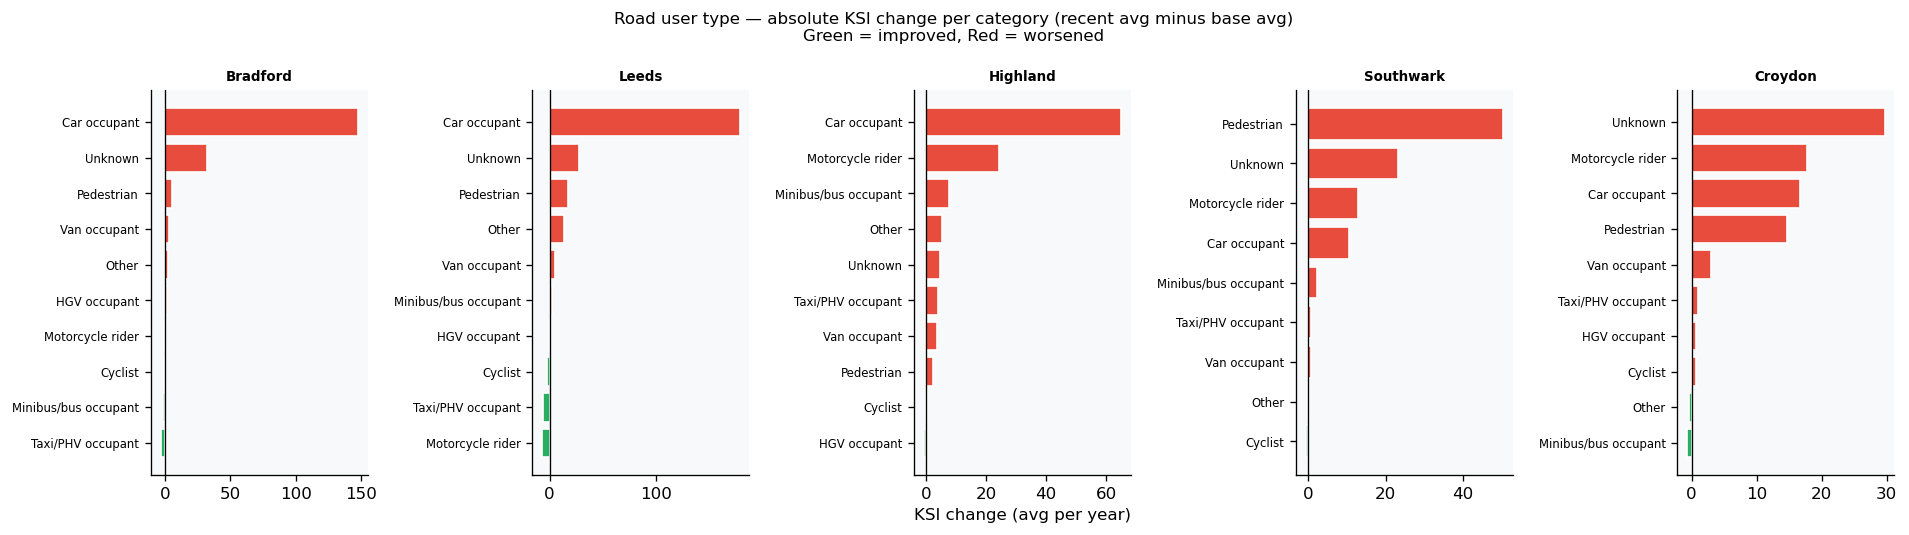

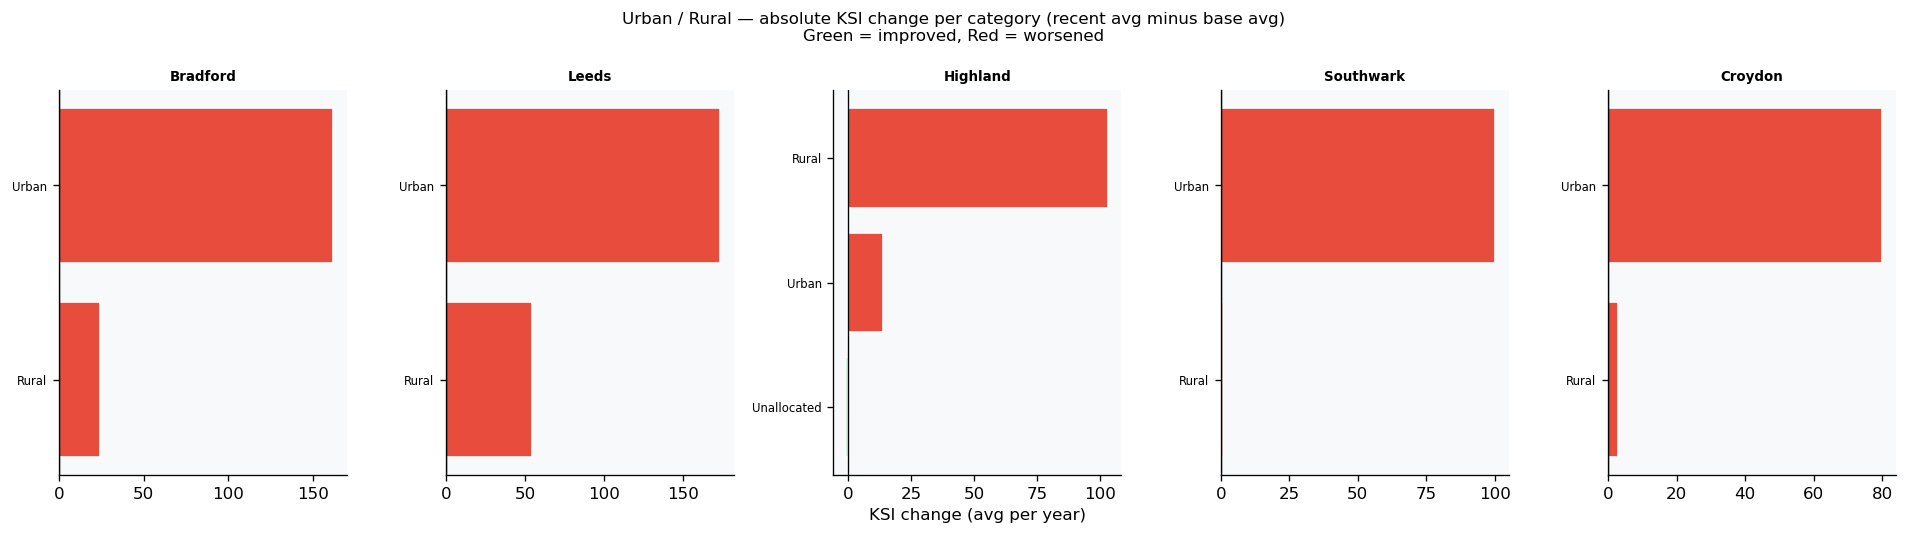

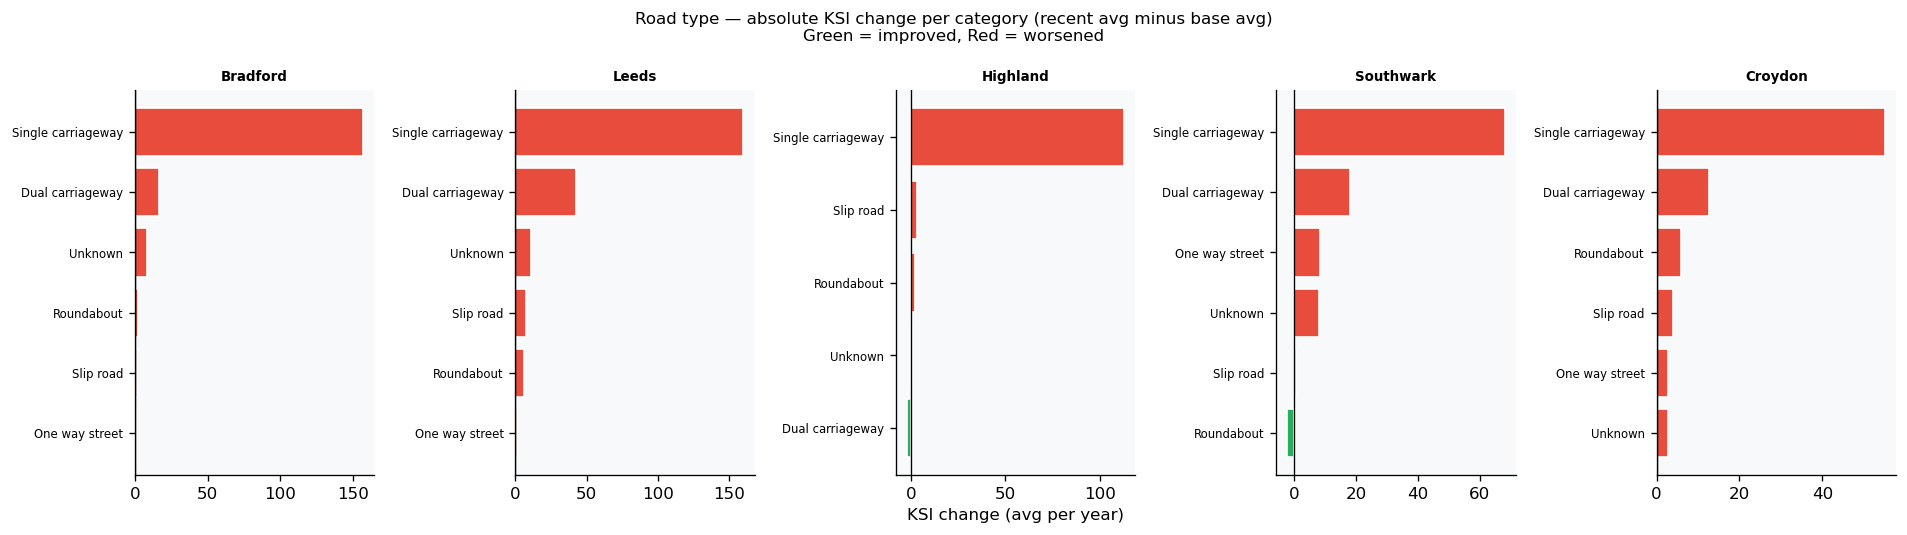

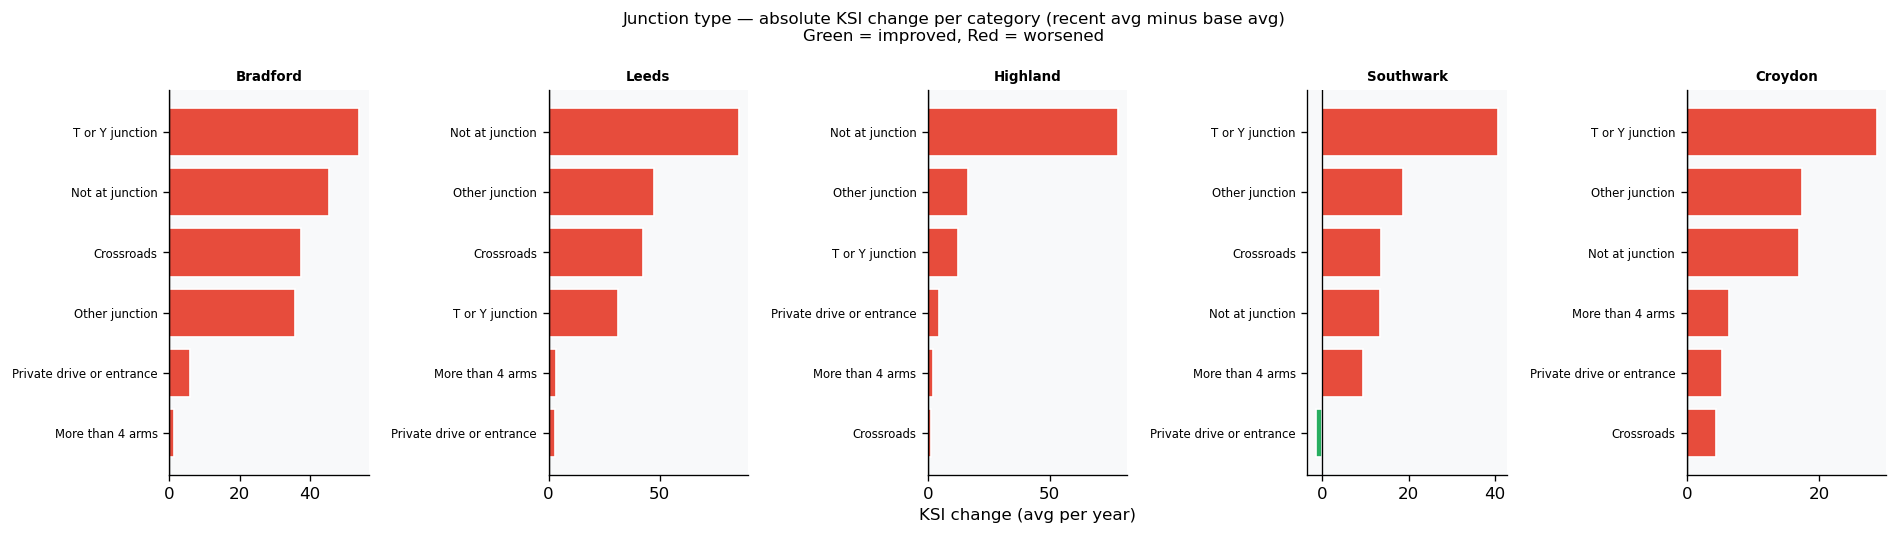

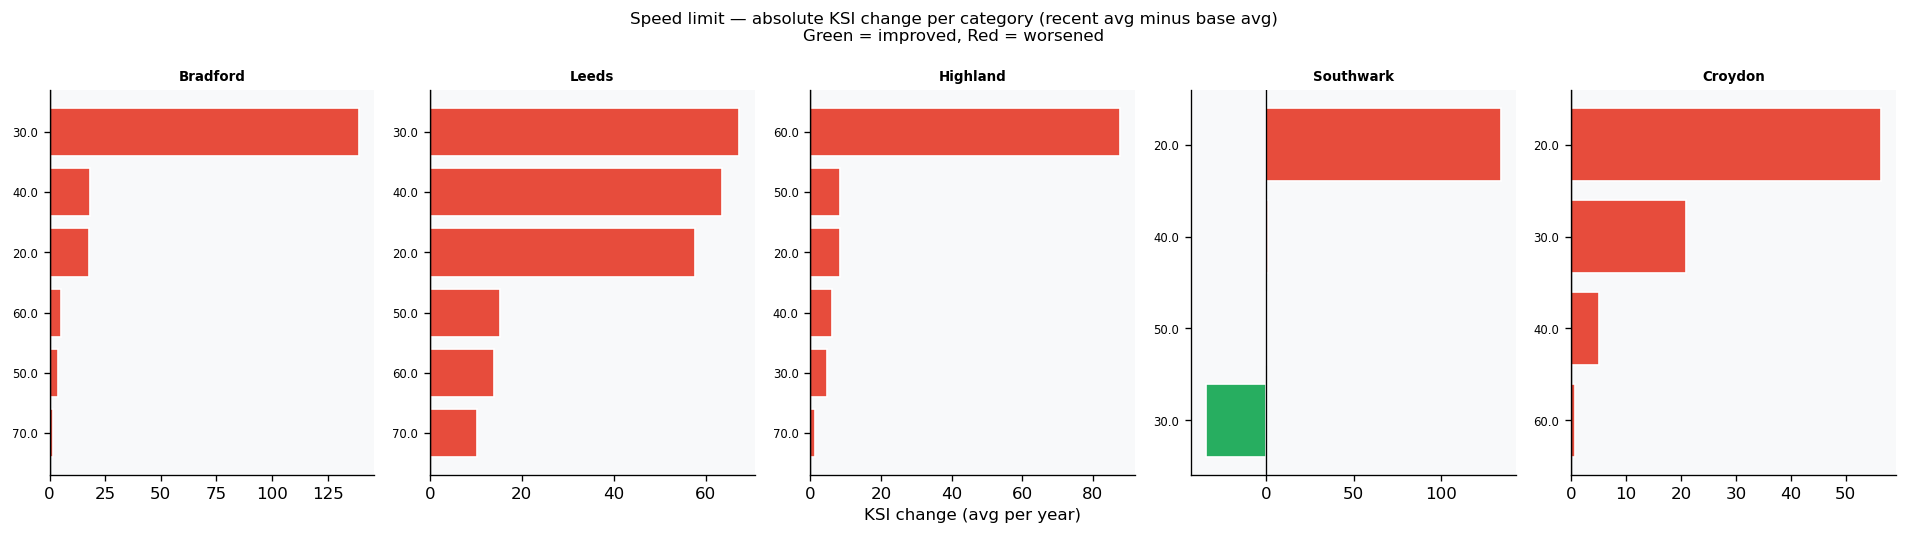

In [28]:
# Absolute KSI change per factor category — what's actually driving the rise?
# Green = that category improved; red = that category got worse

for col, label in FACTORS:
    if col not in deep.columns:
        continue

    n_map = {'Base\n(2015–17)': len(BASE_YEARS), 'Recent\n(2022–24)': len(RECENT_YEARS)}
    grp = (
        deep[deep[col].notna()]
        .groupby(['la_name', 'window', col])
        .size()
        .reset_index(name='ksi_count')
    )
    grp['ksi_avg'] = grp['ksi_count'] / grp['window'].map(n_map)

    pivot = grp.pivot_table(
        index=['la_name', col], columns='window',
        values='ksi_avg', fill_value=0
    ).reset_index()
    pivot.columns.name = None
    for w in ['Base\n(2015–17)', 'Recent\n(2022–24)']:
        if w not in pivot.columns:
            pivot[w] = 0
    pivot['rise'] = pivot['Recent\n(2022–24)'] - pivot['Base\n(2015–17)']

    fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=False)
    fig.suptitle(
        f'{label} — absolute KSI change per category (recent avg minus base avg)\n'
        'Green = improved, Red = worsened',
        fontsize=10
    )

    for ax, la in zip(axes, top5_names):
        sub = pivot[pivot['la_name'] == la].sort_values('rise')
        colors = ['#27ae60' if v <= 0 else '#e74c3c' for v in sub['rise']]
        ax.barh(sub[col].astype(str), sub['rise'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(la, fontsize=8, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        if ax == axes[2]:
            ax.set_xlabel('KSI change (avg per year)')

    plt.tight_layout()
    plt.show()